# Machine Failure Data — Predictive Maintenance Analysis

**Dataset:** `machine_failure_data.csv` — sensor and operational records with timestamps  
**Target:** `Failure_Status` (binary: 0 = no failure, 1 = failure)  
**Features:** Temperature, Pressure, Vibration_Level, Humidity, Power_Consumption, Machine_ID, Timestamp

In [8]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

%matplotlib inline
warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid', palette='muted', font_scale=1.1)
plt.rcParams['figure.dpi'] = 110

DATA_PATH = '../data/raw_data/machine_failure_data.csv'
df = pd.read_csv(DATA_PATH)

df.columns = df.columns.str.strip()
df['Timestamp'] = pd.to_datetime(df['Timestamp'])

print(f'Shape: {df.shape}')
df.head()

Shape: (3000, 8)


,Machine_ID,Timestamp,Temperature,Pressure,Vibration_Level,Humidity,Power_Consumption,Failure_Status
0,MACHINE_001,2025-01-01 00:00:00,56.23,106.00,3.75,77.50,92.06,0
1,MACHINE_002,2025-01-01 00:10:00,36.45,179.39,8.02,74.75,30.30,0
2,MACHINE_003,2025-01-01 00:20:00,64.44,432.66,4.38,62.55,38.74,0
3,MACHINE_004,2025-01-01 00:30:00,23.28,407.56,4.77,38.96,58.70,0
4,MACHINE_005,2025-01-01 00:40:00,27.35,197.15,8.81,50.49,35.34,1


## 1. Dataset Overview

=== Data Types ===
Machine_ID                      str
Timestamp            datetime64[us]
Temperature                 float64
Pressure                    float64
Vibration_Level             float64
Humidity                    float64
Power_Consumption           float64
Failure_Status                int64
dtype: object

=== Basic Statistics ===


,count,unique,top,freq,mean,min,25%,50%,75%,max,std
Machine_ID,3000,3000,MACHINE_001,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Timestamp,3000,NaN,NaN,NaN,2025-01-11 09:55:00,2025-01-01 00:00:00,2025-01-06 04:57:30,2025-01-11 09:55:00,2025-01-16 14:52:30,2025-01-21 19:50:00,NaN
Temperature,3000.0,NaN,NaN,NaN,50.20313,20.02,34.87,50.685,65.415,79.98,17.40254
Pressure,3000.0,NaN,NaN,NaN,299.459657,100.2,199.0175,300.555,402.8575,499.74,116.434739
Vibration_Level,3000.0,NaN,NaN,NaN,5.056363,0.1,2.6175,5.055,7.57,10.0,2.846718
Humidity,3000.0,NaN,NaN,NaN,60.083897,30.01,45.5375,59.665,74.9625,89.95,17.249262
Power_Consumption,3000.0,NaN,NaN,NaN,52.291147,5.02,28.2975,52.52,75.8275,99.99,27.369495
Failure_Status,3000.0,NaN,NaN,NaN,0.099333,0.0,0.0,0.0,0.0,1.0,0.299159


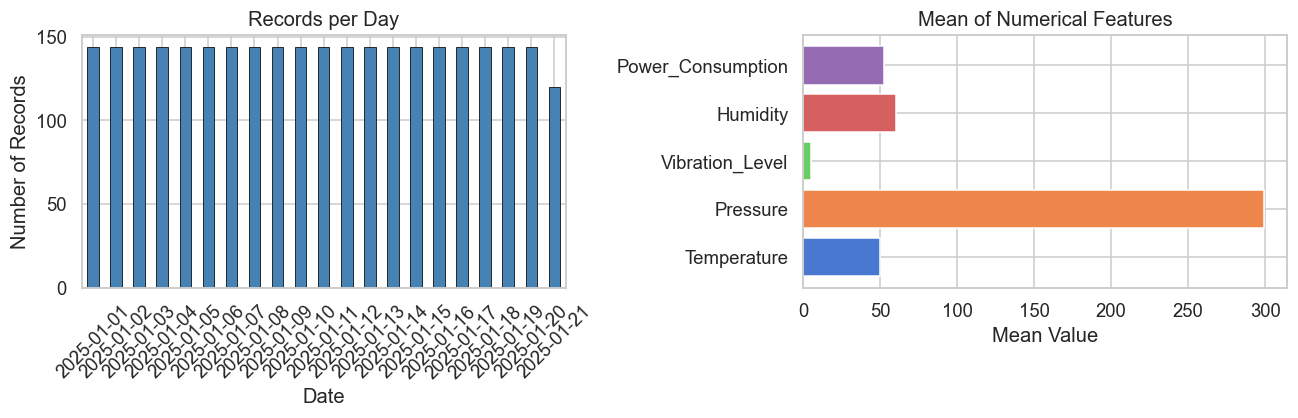

In [9]:
print('=== Data Types ===')
print(df.dtypes)
print('\n=== Basic Statistics ===')
display(df.describe(include='all').T)

# Overview chart: record count and feature ranges
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
daily_counts = df.groupby(df['Timestamp'].dt.date).size()
daily_counts.plot(kind='bar', ax=axes[0], color='steelblue', edgecolor='black', linewidth=0.5)
axes[0].set_xlabel('Date')
axes[0].set_ylabel('Number of Records')
axes[0].set_title('Records per Day')
axes[0].tick_params(axis='x', rotation=45)

num_cols = ['Temperature', 'Pressure', 'Vibration_Level', 'Humidity', 'Power_Consumption']
means = df[num_cols].mean()
axes[1].barh(means.index, means.values, color=sns.color_palette('muted', len(num_cols)))
axes[1].set_xlabel('Mean Value')
axes[1].set_title('Mean of Numerical Features')
plt.tight_layout()
plt.show()

## 2. Target Variable — Machine Failure (Failure_Status)

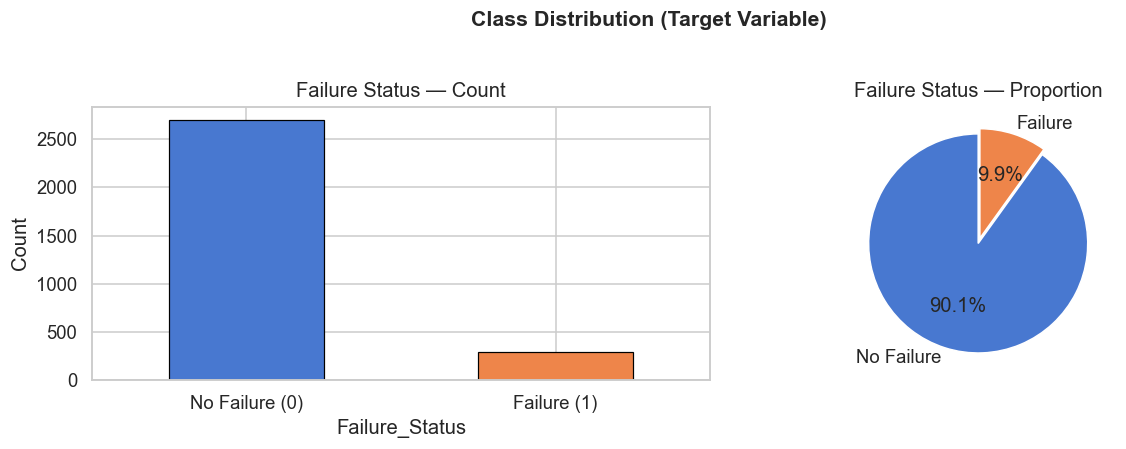

Failure rate: 9.93%


In [10]:
failure_counts = df['Failure_Status'].value_counts()
failure_pct = df['Failure_Status'].value_counts(normalize=True) * 100

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
colors = sns.color_palette('muted')[:2]
failure_counts.plot(kind='bar', ax=axes[0], color=colors, edgecolor='black', linewidth=0.8)
axes[0].set_xticklabels(['No Failure (0)', 'Failure (1)'], rotation=0)
axes[0].set_ylabel('Count')
axes[0].set_title('Failure Status — Count')

axes[1].pie(failure_counts, labels=['No Failure', 'Failure'], autopct='%1.1f%%', colors=colors, startangle=90, explode=(0, 0.05))
axes[1].set_title('Failure Status — Proportion')
plt.suptitle('Class Distribution (Target Variable)', fontsize=14, y=1.02, fontweight='bold')
plt.tight_layout()
plt.show()

print(f'Failure rate: {failure_pct.get(1, 0):.2f}%')

## 3. Failures by Machine ID

Machines with at least one failure: 298 / 3000

Top 10 machines by failure count:


,Failures,Readings,Failure_Rate_Pct
Machine_ID,,,
MACHINE_005,1,1,100.0
MACHINE_014,1,1,100.0
MACHINE_036,1,1,100.0
MACHINE_056,1,1,100.0
MACHINE_067,1,1,100.0
MACHINE_075,1,1,100.0
MACHINE_076,1,1,100.0
MACHINE_080,1,1,100.0
MACHINE_083,1,1,100.0


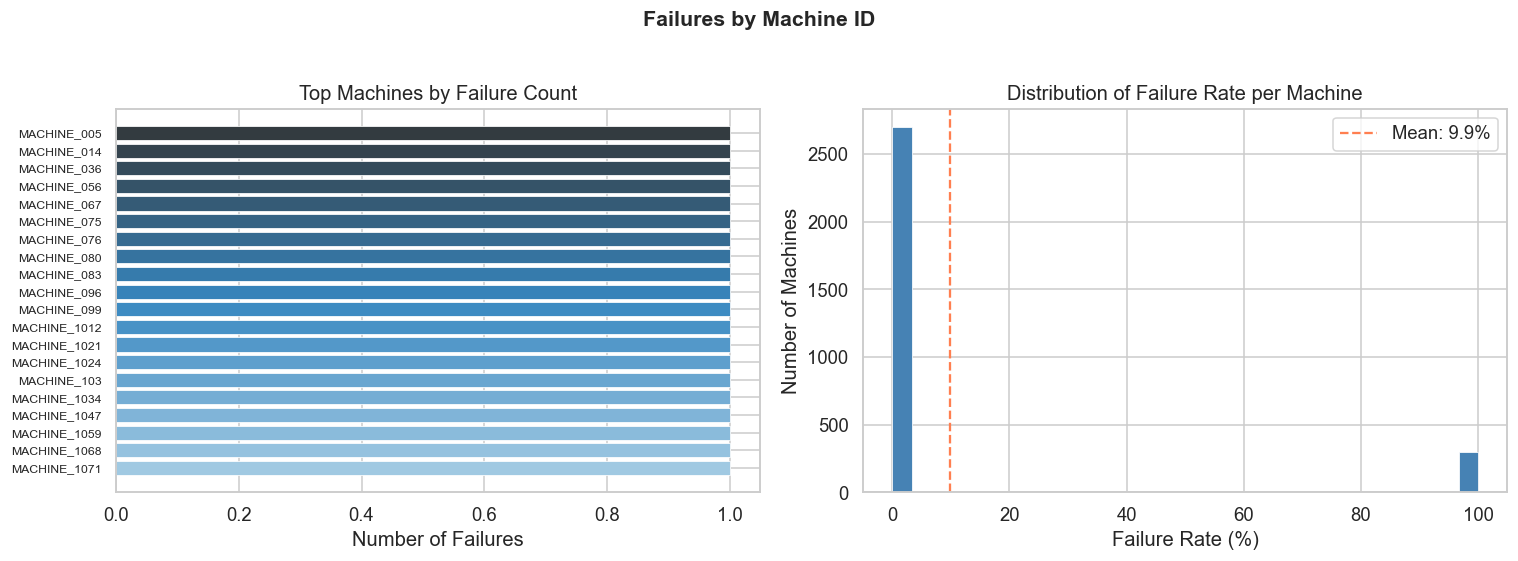

In [11]:
# Failures per machine (each row is one reading per machine at a timestamp)
fail_by_machine = df.groupby('Machine_ID')['Failure_Status'].agg(['sum', 'count', 'mean'])
fail_by_machine.columns = ['Failures', 'Readings', 'Failure_Rate']
fail_by_machine['Failure_Rate_Pct'] = fail_by_machine['Failure_Rate'] * 100

machines_with_failures = (fail_by_machine['Failures'] > 0).sum()
print(f'Machines with at least one failure: {machines_with_failures} / {len(fail_by_machine)}')
print('\nTop 10 machines by failure count:')
display(fail_by_machine.nlargest(10, 'Failures')[['Failures', 'Readings', 'Failure_Rate_Pct']])

# Charts: top machines by failures + failure rate distribution
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
top_n = min(20, len(fail_by_machine))
top_fail = fail_by_machine.nlargest(top_n, 'Failures')
axes[0].barh(range(len(top_fail)), top_fail['Failures'].values, color=sns.color_palette('Blues_d', top_n)[::-1], edgecolor='white', linewidth=0.5)
axes[0].set_yticks(range(len(top_fail)))
axes[0].set_yticklabels(top_fail.index, fontsize=8)
axes[0].set_xlabel('Number of Failures')
axes[0].set_title('Top Machines by Failure Count')
axes[0].invert_yaxis()

fail_rates = fail_by_machine['Failure_Rate_Pct']
axes[1].hist(fail_rates, bins=min(30, len(fail_rates)), color='steelblue', edgecolor='white', linewidth=0.5)
axes[1].axvline(fail_rates.mean(), color='coral', linestyle='--', label=f'Mean: {fail_rates.mean():.1f}%')
axes[1].set_xlabel('Failure Rate (%)')
axes[1].set_ylabel('Number of Machines')
axes[1].set_title('Distribution of Failure Rate per Machine')
axes[1].legend()
plt.suptitle('Failures by Machine ID', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

## 4. Numerical Feature Distributions

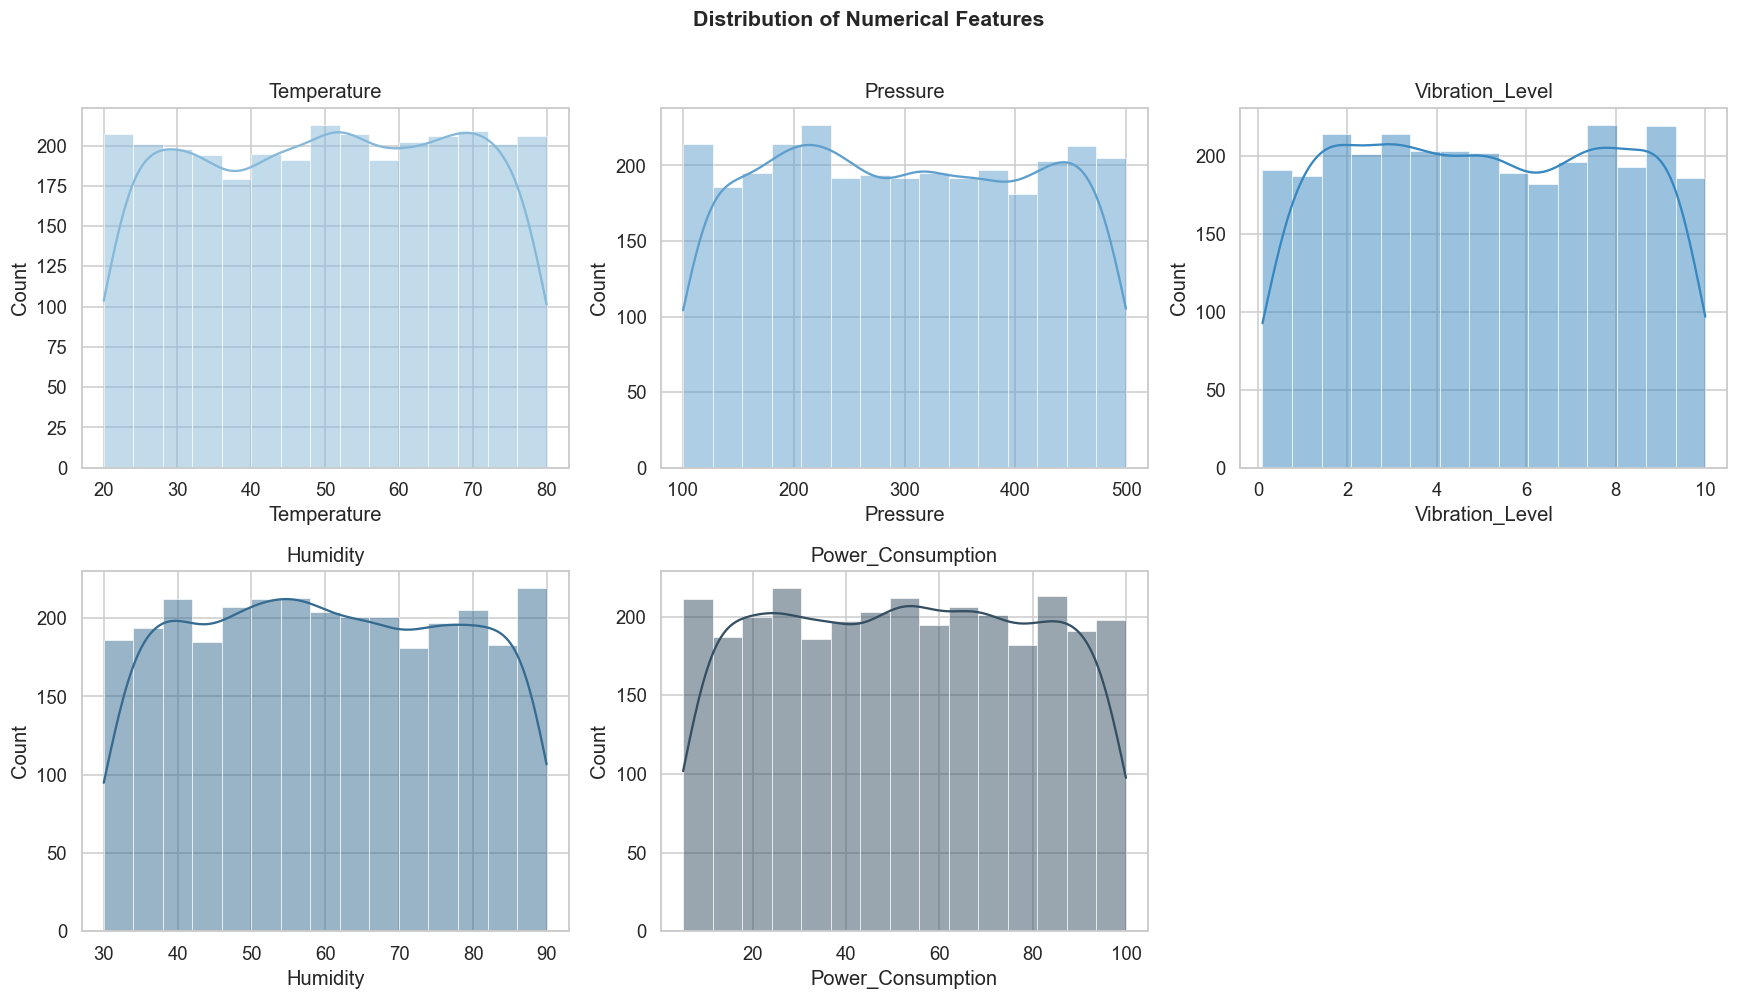

In [12]:
num_features = ['Temperature', 'Pressure', 'Vibration_Level', 'Humidity', 'Power_Consumption']
fig, axes = plt.subplots(2, 3, figsize=(16, 9))
axes = axes.flatten()
colors = sns.color_palette('Blues_d', len(num_features))
for i, col in enumerate(num_features):
    sns.histplot(df[col], kde=True, ax=axes[i], color=colors[i], edgecolor='white', linewidth=0.4)
    axes[i].set_title(col)
axes[-1].set_visible(False)
plt.suptitle('Distribution of Numerical Features', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

## 5. Box Plots — Features by Failure Status

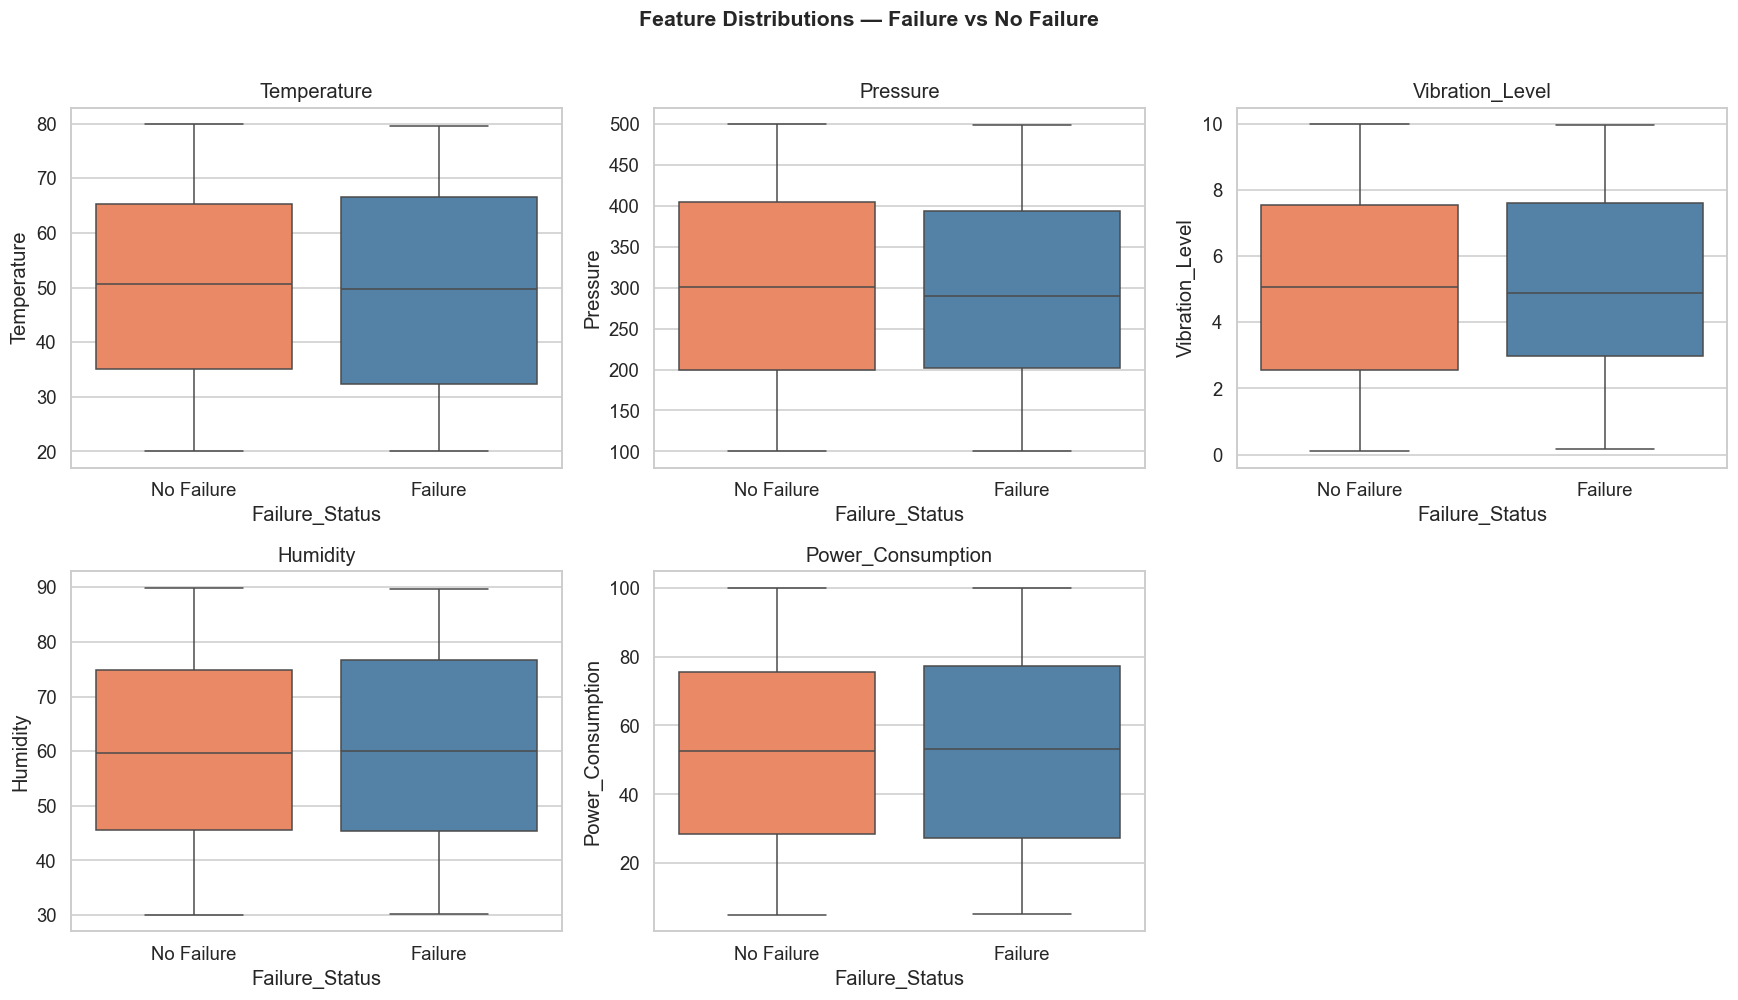

In [14]:
fig, axes = plt.subplots(2, 3, figsize=(16, 9))
axes = axes.flatten()
for i, col in enumerate(num_features):
    sns.boxplot(data=df, x='Failure_Status', y=col, ax=axes[i], palette={'steelblue', 'coral'})
    axes[i].set_xticklabels(['No Failure', 'Failure'])
    axes[i].set_title(col)
axes[-1].set_visible(False)
plt.suptitle('Feature Distributions — Failure vs No Failure', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

## 5b. Violin Plots — Features by Failure Status

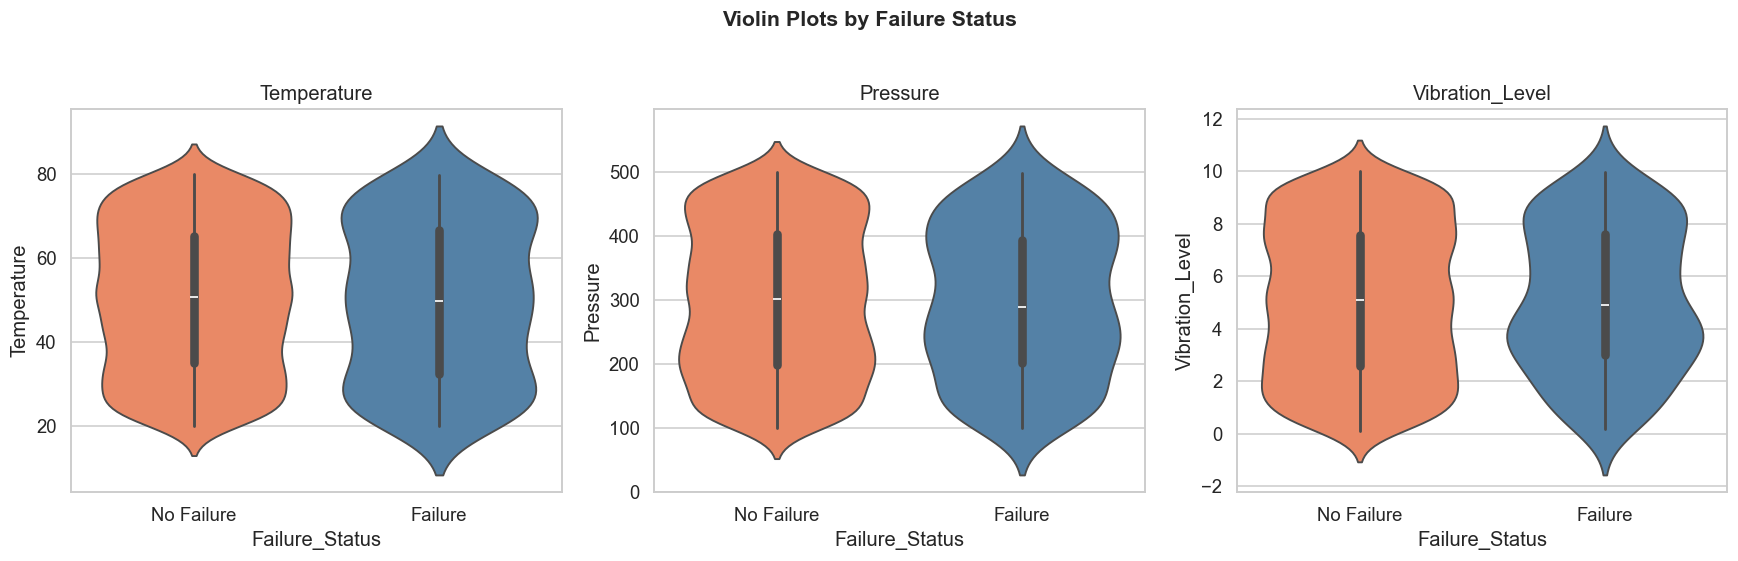

ValueError: The palette dictionary is missing keys: {'1', '0'}

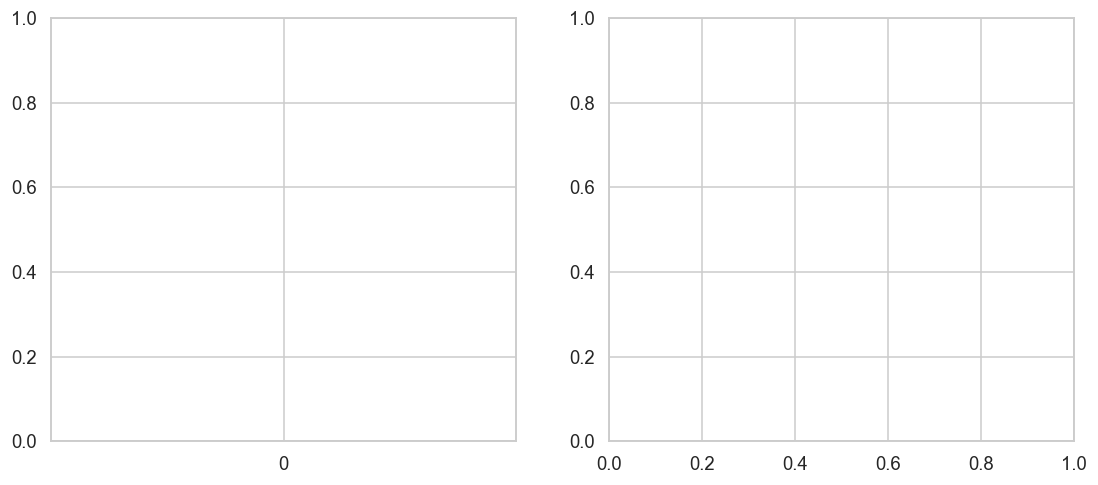

In [16]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
plot_features = ['Temperature', 'Pressure', 'Vibration_Level']
for i, col in enumerate(plot_features):
    sns.violinplot(data=df, x='Failure_Status', y=col, ax=axes[i], palette={'steelblue','coral'})
    axes[i].set_xticklabels(['No Failure', 'Failure'])
    axes[i].set_title(col)
plt.suptitle('Violin Plots by Failure Status', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
for i, col in enumerate(['Humidity', 'Power_Consumption']):
    sns.violinplot(data=df, x='Failure_Status', y=col, ax=axes[i], palette={0: 'steelblue', 1: 'coral'})
    axes[i].set_xticklabels(['No Failure', 'Failure'])
    axes[i].set_title(col)
plt.suptitle('Violin Plots by Failure Status (continued)', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

## 6. Correlation Heatmap

In [ ]:
corr_cols = num_features + ['Failure_Status']
corr = df[corr_cols].corr()
fig, ax = plt.subplots(figsize=(11, 8))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', center=0, square=True, linewidths=0.5, ax=ax)
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.title('Correlation — Numerical Features & Failure_Status', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

## 7. Scatter Plots — Key Feature Interactions

In [ ]:
sample = df.sample(min(800, len(df)), random_state=42)
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

for label, grp in sample.groupby('Failure_Status'):
    axes[0].scatter(grp['Temperature'], grp['Pressure'], alpha=0.5, label='Failure' if label == 1 else 'No Failure', s=25)
axes[0].set_xlabel('Temperature')
axes[0].set_ylabel('Pressure')
axes[0].set_title('Temperature vs Pressure')
axes[0].legend()

for label, grp in sample.groupby('Failure_Status'):
    axes[1].scatter(grp['Vibration_Level'], grp['Power_Consumption'], alpha=0.5, label='Failure' if label == 1 else 'No Failure', s=25)
axes[1].set_xlabel('Vibration_Level')
axes[1].set_ylabel('Power_Consumption')
axes[1].set_title('Vibration vs Power Consumption')
axes[1].legend()

for label, grp in sample.groupby('Failure_Status'):
    axes[2].scatter(grp['Humidity'], grp['Temperature'], alpha=0.5, label='Failure' if label == 1 else 'No Failure', s=25)
axes[2].set_xlabel('Humidity')
axes[2].set_ylabel('Temperature')
axes[2].set_title('Humidity vs Temperature')
axes[2].legend()
plt.suptitle('Scatter Plots — Key Feature Interactions (coloured by Failure)', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

## 8. Failures Over Time

In [ ]:
df['Date'] = df['Timestamp'].dt.date
daily_failures = df.groupby('Date')['Failure_Status'].agg(['sum', 'count', 'mean'])
daily_failures.columns = ['Failures', 'Readings', 'Failure_Rate']

fig, axes = plt.subplots(2, 1, figsize=(14, 6))
daily_failures['Failures'].plot(ax=axes[0], marker='o', markersize=5, color='steelblue')
axes[0].set_ylabel('Number of Failures')
axes[0].set_title('Daily Failure Count')
axes[0].grid(True, alpha=0.3)

daily_failures['Failure_Rate'].plot(ax=axes[1], color='coral', marker='o', markersize=5)
axes[1].set_ylabel('Failure Rate')
axes[1].set_xlabel('Date')
axes[1].set_title('Daily Failure Rate')
axes[1].grid(True, alpha=0.3)
plt.suptitle('Failures Over Time', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

## 9. Pairplot — Core Features Coloured by Failure (subsample)

In [ ]:
pair_cols = ['Temperature', 'Pressure', 'Vibration_Level', 'Humidity', 'Power_Consumption', 'Failure_Status']
pair_df = df[pair_cols].copy()
pair_df['Failure_Status'] = pair_df['Failure_Status'].map({0: 'No Failure', 1: 'Failure'})
sample = pair_df.sample(min(500, len(pair_df)), random_state=42)
g = sns.pairplot(sample, hue='Failure_Status', palette={'No Failure': 'steelblue', 'Failure': 'coral'}, diag_kind='kde', plot_kws={'alpha': 0.6})
g.fig.suptitle('Pairplot — Features by Failure Status (subsample)', y=1.02, fontsize=14, fontweight='bold')
plt.show()